In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.tools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn import metrics

pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42  
TEST_SIZE = 0.2

In [2]:
expectancy_data = pd.read_csv('../Life Expectancy Data.csv')


expectancy_data.columns = [c.strip().replace(' ', '_').replace('/', '_') for c in expectancy_data.columns]

expectancy_data.shape

(2864, 21)

# Explore Data

In [3]:
expectancy_data.columns

Index(['Country', 'Region', 'Year', 'Infant_deaths', 'Under_five_deaths',
       'Adult_mortality', 'Alcohol_consumption', 'Hepatitis_B', 'Measles',
       'BMI', 'Polio', 'Diphtheria', 'Incidents_HIV', 'GDP_per_capita',
       'Population_mln', 'Thinness_ten_nineteen_years',
       'Thinness_five_nine_years', 'Schooling', 'Economy_status_Developed',
       'Economy_status_Developing', 'Life_expectancy'],
      dtype='object')

In [4]:
expectancy_data['Region'].unique()

array(['Middle East', 'European Union', 'Asia', 'South America',
       'Central America and Caribbean', 'Rest of Europe', 'Africa',
       'Oceania', 'North America'], dtype=object)

In [5]:
# expectancy_data['Country'].unique()

In [6]:
# TODO: get an overview. head(), dtypes, describe(), shape.
display(expectancy_data.head())
print("\n--- Data Types ---")
print(expectancy_data.dtypes)
display(expectancy_data.describe())
print(f"\nShape: {expectancy_data.shape}")

# Look specifically at which columns are objects and which are numeric
object_cols = expectancy_data.select_dtypes(include=['object']).columns.tolist()
numeric_cols = expectancy_data.select_dtypes(exclude=['object']).columns.tolist()

print(f"\nObject columns: {object_cols}")
print(f"Numeric columns: {numeric_cols}")

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,97,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,97,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,67,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,92,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,94,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7



--- Data Types ---
Country                         object
Region                          object
Year                             int64
Infant_deaths                  float64
Under_five_deaths              float64
Adult_mortality                float64
Alcohol_consumption            float64
Hepatitis_B                      int64
Measles                          int64
BMI                            float64
Polio                            int64
Diphtheria                       int64
Incidents_HIV                  float64
GDP_per_capita                   int64
Population_mln                 float64
Thinness_ten_nineteen_years    float64
Thinness_five_nine_years       float64
Schooling                      float64
Economy_status_Developed         int64
Economy_status_Developing        int64
Life_expectancy                float64
dtype: object


,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
count,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000
mean,2007.500000,30.363792,42.938268,192.251775,4.820882,84.292598,77.344972,25.032926,86.499651,86.271648,0.894288,11540.924930,36.675915,4.865852,4.899825,7.632123,0.206704,0.793296,68.856075
std,4.610577,27.538117,44.569974,114.910281,3.981949,15.995511,18.659693,2.193905,15.080365,15.534225,2.381389,16934.788931,136.485867,4.438234,4.525217,3.171556,0.405012,0.405012,9.405608
min,2000.000000,1.800000,2.300000,49.384000,0.000000,12.000000,10.000000,19.800000,8.000000,16.000000,0.010000,148.000000,0.080000,0.100000,0.100000,1.100000,0.000000,0.000000,39.400000
25%,2003.750000,8.100000,9.675000,106.910250,1.200000,78.000000,64.000000,23.200000,81.000000,81.000000,0.080000,1415.750000,2.097500,1.600000,1.600000,5.100000,0.000000,1.000000,62.700000
50%,2007.500000,19.600000,23.100000,163.841500,4.020000,89.000000,83.000000,25.500000,93.000000,93.000000,0.150000,4217.000000,7.850000,3.300000,3.400000,7.800000,0.000000,1.000000,71.400000
75%,2011.250000,47.350000,66.000000,246.791375,7.777500,96.000000,93.000000,26.400000,97.000000,97.000000,0.460000,12557.000000,23.687500,7.200000,7.300000,10.300000,0.000000,1.000000,75.400000
max,2015.000000,138.100000,224.900000,719.360500,17.870000,99.000000,99.000000,32.100000,99.000000,99.000000,21.680000,112418.000000,1379.860000,27.700000,28.600000,14.100000,1.000000,1.000000,83.800000



Shape: (2864, 21)

Object columns: ['Country', 'Region']
Numeric columns: ['Year', 'Infant_deaths', 'Under_five_deaths', 'Adult_mortality', 'Alcohol_consumption', 'Hepatitis_B', 'Measles', 'BMI', 'Polio', 'Diphtheria', 'Incidents_HIV', 'GDP_per_capita', 'Population_mln', 'Thinness_ten_nineteen_years', 'Thinness_five_nine_years', 'Schooling', 'Economy_status_Developed', 'Economy_status_Developing', 'Life_expectancy']


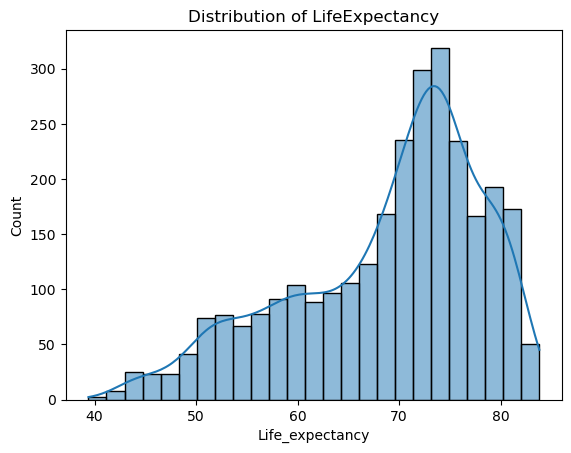


Strongest correlations with LifeExpectancy:
 Life_expectancy             1.000000
Schooling                   0.732484
Polio                       0.641217
Diphtheria                  0.627541
BMI                         0.598423
GDP_per_capita              0.583090
Economy_status_Developed    0.523791
Measles                     0.490019
Hepatitis_B                 0.417804
Alcohol_consumption         0.399159
Name: Life_expectancy, dtype: float64

Weakest correlations with LifeExpectancy:
 Economy_status_Developing   -0.523791
Incidents_HIV               -0.553027
Infant_deaths               -0.920032
Under_five_deaths           -0.920419
Adult_mortality             -0.945360
Name: Life_expectancy, dtype: float64


In [7]:
# TODO: look at the distribution of Life Expectancy and at the strongest correlations with it.
sns.histplot(expectancy_data['Life_expectancy'], kde=True)
plt.title('Distribution of LifeExpectancy')
plt.show()

# Calculate correlations for numeric columns only
numeric_df = expectancy_data.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['Life_expectancy'].sort_values(ascending=False)
print("\nStrongest correlations with LifeExpectancy:\n", correlations.head(10))
print("\nWeakest correlations with LifeExpectancy:\n", correlations.tail(5))

In [8]:
#sns.pairplot(expectancy_data)
#plt.show()

# Check Nulls

In [9]:
# TODO: count the nulls in every column and show only the columns that have any.
nulls = expectancy_data.isnull().sum()
print(nulls[nulls > 0].sort_values(ascending=False))

Series([], dtype: int64)


# One Hot Encoding Regions

In [10]:
df = pd.get_dummies(expectancy_data, columns=['Region'], drop_first=True)

In [11]:
region_columns = [col for col in df.columns if col.startswith('Region_')]
print(region_columns)

['Region_Asia', 'Region_Central America and Caribbean', 'Region_European Union', 'Region_Middle East', 'Region_North America', 'Region_Oceania', 'Region_Rest of Europe', 'Region_South America']


# Split Data

In [12]:
# Model 1: Least Information (Privacy-Preserving)
least_information_columns = [
    "Life_expectancy",
    "Year",
    "Economy_status_Developed",
    "Economy_status_Developing",
    "Population_mln",
    "GDP_per_capita",
    "Schooling"
]

# Model 2: Elaborate (All Features)
# This includes the base features above, plus all sensitive medical/health records.
elaborate_columns = [
    "Life_expectancy",
    "Economy_status_Developed",
    "Economy_status_Developing",
    "Population_mln",
    "GDP_per_capita",
    "Schooling",
    "Infant_deaths",
    "Under_five_deaths",
    "Adult_mortality",
    "Alcohol_consumption",
    "Hepatitis_B",
    "Measles",
    "BMI",
    "Polio",
    "Diphtheria",
    "Incidents_HIV",
    "Thinness_ten_nineteen_years",
    "Thinness_five_nine_years",
    "Year"
] + region_columns

In [13]:
#least_information_columns = least_base + region_columns
# elaborate_columns = elaborate_base + region_columns

In [14]:
df_least = df[least_information_columns]
df_elaborate = df[elaborate_columns]

# Country is never a feature, but we need it to group the split (see below)
groups = df['Country']


In [15]:
print('Region' in df.columns)

False


In [16]:
# Removing duplicate info otherwise, model only needs 1 column to infer status

df_elaborate.drop(columns="Economy_status_Developed", inplace=True)

In [17]:
df_elaborate['GDP_per_capita_log'] = np.log(df_elaborate['GDP_per_capita'])
df_elaborate = df_elaborate.drop(columns=['GDP_per_capita'])

# Splitting data

In [18]:
# old one - previous random split, kept for reference only.
# Left commented out so a full run can't overwrite the grouped split below.

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
# )

In [19]:
TARGET = 'Life_expectancy'

X = df_elaborate.drop(columns=[TARGET])
y = df_elaborate[TARGET]

# Each country contributes 16 yearly rows that barely differ from one another, so a
# random split leaves near-duplicates of every test row sitting in the training set.
# Grouping on Country keeps all of a country's rows on the same side of the split.
#splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
#train_idx, test_idx = next(splitter.split(X, y, groups=groups))



#X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
#y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
 )

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
#print('Countries in both splits:', len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])))
print('Features:', list(X_train.columns))

X_train: (2291, 25)
X_test:  (573, 25)
Features: ['Economy_status_Developing', 'Population_mln', 'Schooling', 'Infant_deaths', 'Under_five_deaths', 'Adult_mortality', 'Alcohol_consumption', 'Hepatitis_B', 'Measles', 'BMI', 'Polio', 'Diphtheria', 'Incidents_HIV', 'Thinness_ten_nineteen_years', 'Thinness_five_nine_years', 'Year', 'Region_Asia', 'Region_Central America and Caribbean', 'Region_European Union', 'Region_Middle East', 'Region_North America', 'Region_Oceania', 'Region_Rest of Europe', 'Region_South America', 'GDP_per_capita_log']


# Feature Engineering

In [20]:
def add_gdp_log(X_df):
    X_df = X_df.copy()
    if 'GDP_per_capita' in X_df.columns:
        X_df['GDP_per_capita_log'] = np.log(X_df['GDP_per_capita'])
        X_df = X_df.drop(columns=['GDP_per_capita'])
    return X_df
X_train = add_gdp_log(X_train)
X_test  = add_gdp_log(X_test)

X_train.head()

,Economy_status_Developing,Population_mln,Schooling,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,Thinness_ten_nineteen_years,Thinness_five_nine_years,Year,Region_Asia,Region_Central America and Caribbean,Region_European Union,Region_Middle East,Region_North America,Region_Oceania,Region_Rest of Europe,Region_South America,GDP_per_capita_log
2026,1,20.78,10.9,7.9,9.3,111.2825,2.45,99,99,22.9,99,99,0.01,15.2,15.0,2014,True,False,False,False,False,False,False,False,8.214465
651,0,10.20,11.6,3.7,4.6,114.2985,13.42,98,98,26.6,96,98,0.08,2.1,2.2,2004,False,False,True,False,False,False,False,False,9.551800
2225,1,30.04,10.0,15.4,18.0,143.0785,6.60,78,83,26.6,79,78,0.40,1.6,1.5,2014,False,False,False,False,False,False,False,True,9.683838
2357,1,2.91,9.3,11.8,13.3,80.9365,4.88,99,98,26.1,99,99,0.03,1.4,1.5,2010,False,False,False,False,False,False,True,False,8.182280
670,1,1.88,5.8,43.3,74.4,495.7265,2.29,83,64,23.2,82,79,9.74,14.2,14.3,2003,False,False,False,False,False,False,False,False,8.101072


# Fit Model and Evaluate Baseline RMSE

In [21]:
def fit_and_score(X_tr, X_te, y_tr, y_te, label=''):
    m = LinearRegression()
    m.fit(X_tr, y_tr)
    preds = m.predict(X_te)
    rmse = metrics.root_mean_squared_error(y_te, preds)
    r2 = metrics.r2_score(y_te, preds)
    if label:
        print(f'{label:<40} RMSE: {rmse:.4f}   R2: {r2:.4f}')
    return m, rmse


results = {}

baseline_model, baseline_rmse = fit_and_score(
    X_train, X_test, y_train, y_test, 'Baseline (all features)'
)
results['Baseline (all features)'] = baseline_rmse



Baseline (all features)                  RMSE: 1.2160   R2: 0.9822


# Validate Columns to Drop

In [22]:
# stepwise

def stepwise_selection(X, y, threshold_in = 0.01, threshold_out = 0.05, verbose = True):
    # The function is checking for p-values (whether features are statistically significant) - lower is better
    included = [] # this is going to be the list of features we keep
    while True:
        changed = False
        # forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index = excluded, dtype = 'float64')
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        # we add the feature with the lowest (best) p-value under the threshold to our 'included' list
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval)) # specifying the verbose text


        # backward step: removing features if new features added to the list make them statistically insignificant
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()

        # use all coefs except intercept
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() # null if pvalues is empty
        # if the p-value exceeds the upper threshold, the feature will be dropped from the 'included' list
        if worst_pval > threshold_out:
            changed = True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [23]:
X_train_f = X_train.astype(float)  

sel = stepwise_selection(X_train_f, y_train)

print('\nSelected', len(sel), 'of', X_train.shape[1], ':')
print(sel)
print('\nExcluded:', sorted(set(X_train.columns) - set(sel)))

Add  Adult_mortality                with p-value 0.0


Add  Infant_deaths                  with p-value 0.0
Add  Economy_status_Developing      with p-value 1.09931e-84
Add  Region_Central America and Caribbean with p-value 8.7296e-47
Add  Region_South America           with p-value 1.03075e-38
Add  Under_five_deaths              with p-value 7.86972e-27
Add  GDP_per_capita_log             with p-value 2.21333e-30
Add  Region_Oceania                 with p-value 2.84516e-23
Add  Region_European Union          with p-value 2.99249e-25
Add  Schooling                      with p-value 6.70252e-08
Add  BMI                            with p-value 6.56748e-13
Add  Year                           with p-value 6.16713e-08
Add  Hepatitis_B                    with p-value 0.000648365
Add  Incidents_HIV                  with p-value 0.000316316
Add  Polio                          with p-value 0.00995043

Selected 15 of 25 :
['Adult_mortality', 'Infant_deaths', 'Economy_status_Developing', 'Region_Central America and Caribbean', 'Region_South America',

In [24]:
def score(cols, label):
    m = LinearRegression().fit(X_train[cols], y_train)
    tr = metrics.root_mean_squared_error(y_train, m.predict(X_train[cols]))
    te = metrics.root_mean_squared_error(y_test, m.predict(X_test[cols]))
    print(f'{label:<28} train {tr:.4f} | test {te:.4f}')
    return m, te

score(list(X_train.columns), 'All features')
score(sel, 'Stepwise selected')

# RMSE score for the  columns i initially thought of excluding 
redundant = ['Infant_deaths', 'Diphtheria', 'Thinness_five_nine_years']
score([c for c in X_train.columns if c not in redundant], 'Manual redundancy drops')

All features                 train 1.1780 | test 1.2160
Stepwise selected            train 1.1886 | test 1.2174
Manual redundancy drops      train 1.1961 | test 1.2262


(LinearRegression(), 1.2261778574255906)

In [25]:
stepwise_model = LinearRegression().fit(X_train[sel], y_train)
preds = stepwise_model.predict(X_test[sel])

rmse = metrics.root_mean_squared_error(y_test, preds)
print('Stepwise RMSE:', round(rmse, 4))
print('R2:', round(metrics.r2_score(y_test, preds), 4))

Stepwise RMSE: 1.2174
R2: 0.9821


In [26]:
def calculate_vif(X, thresh=10.0):
    X = X.astype(float)
    variables = list(X.columns)
    while True:
        Xc = add_constant(X[variables])
        vif = pd.Series(
            [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])],
            index=Xc.columns
        ).drop('const')
        if vif.max() <= thresh:
            break
        worst = vif.idxmax()
        print(f'dropping {worst} VIF={vif.max():.2f}')
        variables.remove(worst)
    print('Remaining:', variables)
    return variables

In [27]:
# rmse using VIF on the results from stepwise

sel_clean = calculate_vif(X_train[sel])
m = LinearRegression().fit(X_train[sel_clean], y_train)
print('RMSE:', metrics.root_mean_squared_error(y_test, m.predict(X_test[sel_clean])))

dropping Infant_deaths VIF=46.36
Remaining: ['Adult_mortality', 'Economy_status_Developing', 'Region_Central America and Caribbean', 'Region_South America', 'Under_five_deaths', 'GDP_per_capita_log', 'Region_Oceania', 'Region_European Union', 'Schooling', 'BMI', 'Year', 'Hepatitis_B', 'Incidents_HIV', 'Polio']
RMSE: 1.2250179459166342


In [28]:
# testing adding back all regions

sel_final = sel_clean + ['Region_Asia', 'Region_Middle East',
                          'Region_North America', 'Region_Rest of Europe']

m = LinearRegression().fit(X_train[sel_final], y_train)
print('RMSE:', metrics.root_mean_squared_error(y_test, m.predict(X_test[sel_final])))

RMSE: 1.2299323499398158


In [29]:
X_train_sm = sm.add_constant(X_train[sel_clean].astype(float))

ols_model = sm.OLS(y_train, X_train_sm).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Life_expectancy   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     9888.
Date:                Wed, 19 Aug 2026   Prob (F-statistic):               0.00
Time:                        09:25:50   Log-Likelihood:                -3678.2
No. Observations:                2291   AIC:                             7386.
Df Residuals:                    2276   BIC:                             7472.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   13.3871     11.395      1.175      0.240      -8.958      35.732
Adult_mortality                         -0.0465      0.001    -76.412      0.000      -0.048      -0.045
Economy_status_Developing               -2.8019      0.146    -19.167      0.000      -3.089      -2.515
Region_Central America and Caribbean     1.7245      0.093     18.471      0.000       1.541       1.908
Region_South America                     1.4094      0.106     13.296      0.000       1.202       1.617
Under_five_deaths                       -0.0756      0.002    -46.024      0.000      -0.079      -0.072
GDP_per_capita_log                       0.4166      0.039     10.690      0.000       0.340       0.493
Region_Oceania                          -1.0089      0.120     -8.384      0.000      -1.245      -0.773
Region_European Union                   -1.0990      0.131     -8.363      0.000      -1.357      -0.841
Schooling                                0.1191      0.016      7.339      0.000       0.087       0.151
BMI                                     -0.1459      0.019     -7.737      0.000      -0.183      -0.109
Year                                     0.0343      0.006      6.060      0.000       0.023       0.045
Hepatitis_B                             -0.0091      0.002     -3.932      0.000      -0.014      -0.005
Incidents_HIV                            0.0616      0.019      3.320      0.001       0.025       0.098
Polio                                    0.0097      0.003      2.939      0.003       0.003       0.016
==============================================================================
Omnibus:                       32.278   Durbin-Watson:                   2.026
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               45.171
Skew:                           0.166   Prob(JB):                     1.55e-10
Kurtosis:                       3.603   Cond. No.                     9.12e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.12e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""